In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem
from scipy import stats
import seaborn as sns

In [2]:
adata = sc.read_h5ad('CC_GMM_groups_adata.h5ad')

In [3]:
# 1. hk_genes
hk_genes =["Actb", "Rplp0","Hsp90ab1","Ubc","Eef1a1","Ppia","Ywhaz","Gapdh"]
samples_to_remove = ['Label_NC_1', 'Label_NC_2']
adata_cancer = adata[~adata.obs['orig.ident'].isin(samples_to_remove)].copy()
valid_hk = [g for g in hk_genes if g in adata_cancer.var_names]

hk_total = np.asarray(adata_cancer[:, valid_hk].layers['total'].mean(axis=1)).flatten()
hk_new = np.asarray(adata_cancer[:, valid_hk].layers['new'].mean(axis=1)).flatten()
adata_cancer.layers['alpha_fil0'] = np.nan_to_num(adata_cancer.layers['alpha'], nan=0.0)
hk_alpha = np.asarray(adata_cancer[:, valid_hk].layers['alpha_fil0'].mean(axis=1)).flatten()

adata_cancer.obs['HK_nCount_mean'] = hk_total
adata_cancer.obs['HK_new_mean'] = hk_new
adata_cancer.obs['HK_alpha_mean'] = hk_alpha

# 2. filter
valid_mask = (adata_cancer.obs['HK_nCount_mean'] > 0) & \
             (adata_cancer.obs['HK_alpha_mean'] > 0) & \
             (adata_cancer.obs['HK_new_mean'] > 0)

adata_valid = adata_cancer[valid_mask].copy()
print(f"valid cells: {adata_valid.n_obs} (del {adata_cancer.n_obs - adata_valid.n_obs} cells)")

valid cells: 15178 (del 656 cells)


In [4]:
# use top25% and bottom25%
q75 = adata_valid.obs['alpha'].quantile(0.75)
q25 = adata_valid.obs['alpha'].quantile(0.25)
adata_valid.obs['Strict_Kinetics_State'] = 'Middle'
adata_valid.obs.loc[adata_valid.obs['alpha'] >= q75, 'Strict_Kinetics_State'] = 'High'
adata_valid.obs.loc[adata_valid.obs['alpha'] <= q25, 'Strict_Kinetics_State'] = 'Low'
# filter Middle group
adata_valid = adata_valid[adata_valid.obs['Strict_Kinetics_State'] != 'Middle'].copy()

In [5]:
# Housekeeping gene-based normalization
adata_valid.obs['HK_ntr_mean'] = adata_valid.obs['HK_new_mean'] / adata_valid.obs['HK_nCount_mean']
adata_valid.obs['nCount_norm'] = adata_valid.obs['nCount_RNA'] / adata_valid.obs['HK_nCount_mean']
adata_valid.obs['ntr_norm'] = adata_valid.obs['newRNA_ratio'] / adata_valid.obs['HK_ntr_mean']
adata_valid.obs['alpha_norm'] = adata_valid.obs['alpha'] / adata_valid.obs['HK_alpha_mean']

In [6]:
sample_level_df = adata_valid.obs.groupby(['orig.ident', 'Kinetics_State'])[
    ['nCount_norm', 'ntr_norm', 'alpha_norm']
    ].mean().reset_index()

## Min-max scaling to range [0, 1]
metrics = ['nCount_norm', 'ntr_norm', 'alpha_norm']
scaled_metrics = []

for metric in metrics:
    scaled_col = f'{metric}_scaled'
    scaled_metrics.append(scaled_col)
    min_val = sample_level_df[metric].min()
    max_val = sample_level_df[metric].max()
    # Min-Max
    sample_level_df[scaled_col] = (sample_level_df[metric] - min_val) / (max_val - min_val)


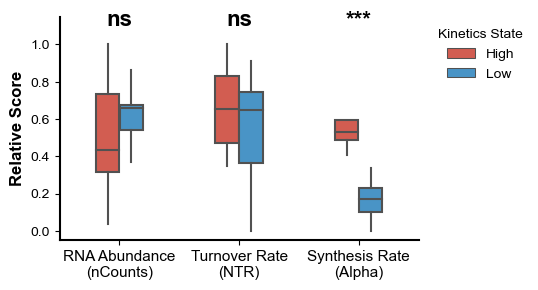

In [7]:
metrics = ['nCount_norm', 'ntr_norm', 'alpha_norm']
scaled_metrics = [f'{m}_scaled' for m in metrics]
titles = ['RNA Abundance\n(nCounts)', 'Turnover Rate\n(NTR)', 'Synthesis Rate\n(Alpha)']
colors = {"Low": "#3498db", "High": "#e74c3c"}
order = ["High","Low"]

# dict
metric_to_title = dict(zip(scaled_metrics, titles))
long_df = pd.melt(sample_level_df, 
                  id_vars=['orig.ident', 'Kinetics_State'], 
                  value_vars=scaled_metrics,
                  var_name='Metric', 
                  value_name='Relative_Score')
long_df['Metric'] = long_df['Metric'].map(metric_to_title)


# plot
fig, ax = plt.subplots(figsize=(5.5, 3))

# boxplot
sns.boxplot(data=long_df, x='Metric', y='Relative_Score', hue='Kinetics_State',
            hue_order=order, palette=colors, ax=ax, width=0.4,
            showfliers=False, linewidth=1.5, showcaps=False)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Kinetics State', 
          frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))


## wilcoxon
y_max = 1.0 
h = 0.08

for i, scaled_metric in enumerate(scaled_metrics):
    group_high = sample_level_df[sample_level_df['Kinetics_State'] == 'High'][scaled_metric].values
    group_low = sample_level_df[sample_level_df['Kinetics_State'] == 'Low'][scaled_metric].values
    
    stat, p_val = stats.wilcoxon(group_high, group_low)
    star = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.text(i, y_max + h, star, ha='center', va='bottom', fontsize=16, fontweight='bold')

ax.set_title('', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Relative Score', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
# plt.savefig("Cancer_cell_compare_boxplot.pdf", format='pdf', bbox_inches='tight')
plt.show()